# Foliage to hex cell

In this example, I'm going to take the output, convert it to hexes, and then save. While I still think it's sensible to filter and not save the full dataset, I want to try out different visualisation options with the full dataset.

In [1]:
# Import required libraries
import laspy
import rasterio
from rasterio.transform import from_bounds
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile
from rasterio.warp import calculate_default_transform, reproject, Resampling
from scipy.interpolate import griddata
from scipy.ndimage import generic_filter
import pdal
import json
from pathlib import Path
import datetime

import rasterio
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile

import glob
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union

import folium
import numpy as np
from scipy.spatial import Voronoi
from shapely.geometry import Polygon
import geopandas as gpd
import json

In [2]:
park_gdf= gpd.read_file("../../processed_datasets/Leeds_Woodhouse_Moor_park_boundaries.geojson")
lidar_dir= "../../example_datasets"
OUTPUT_DIR = Path("../../outputs/foliage_tests")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Analysis parameters
GRID_SPACING = 10  # meters between analysis points
OBSERVER_HEIGHT = 1.0  # meters (eye height)
MAX_DISTANCE = 100  # maximum visibility distance in meters
MIN_VEG_AREA = 2  # minimum vegetation polygon area in sq meters

FILE_NAME = f"Woodhouse_Moor_{GRID_SPACING}_foliage_poly"

Original park CRS: EPSG:4326
Reprojected park to EPSG:27700
Park boundary CRS: EPSG:27700
Original park area: 219119 m²
Buffered park area: 258752 m²


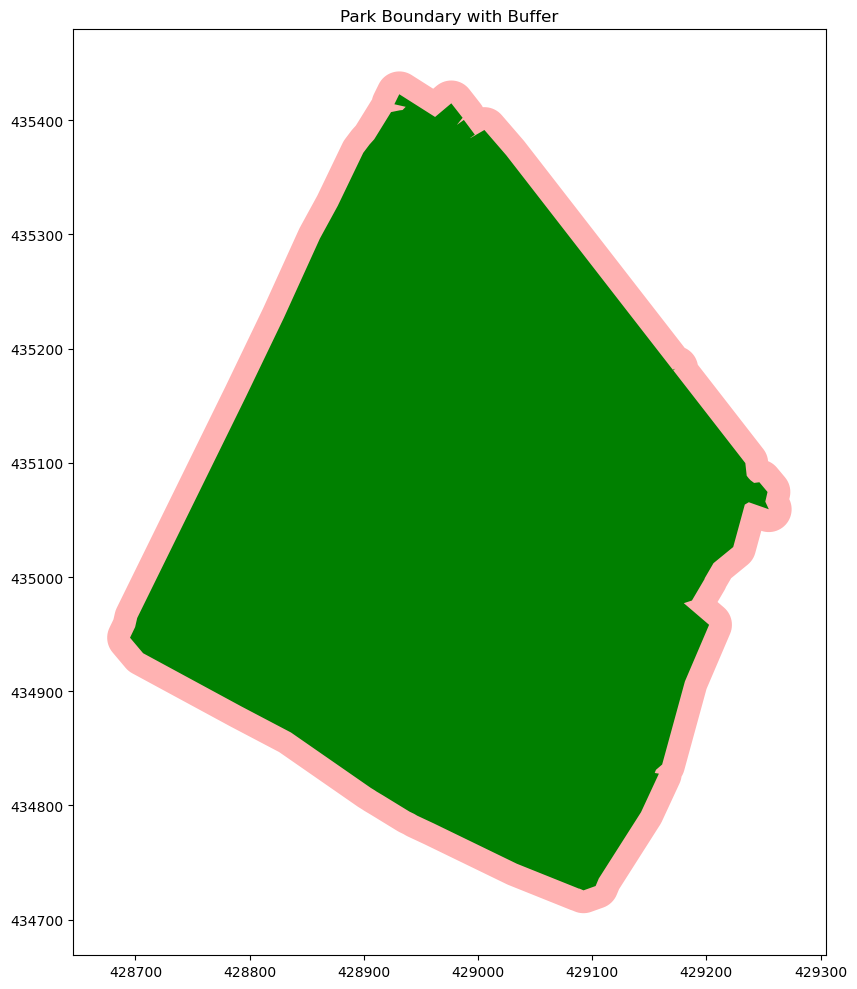

In [3]:
# Park boundary buffer

# Normalize CRS to EPSG:27700 (British National Grid)
TARGET_CRS = 'EPSG:27700'

BUFFER_DISTANCE = 20  # meters

print(f"Original park CRS: {park_gdf.crs}")

# Reproject park to target CRS if needed
if park_gdf.crs != TARGET_CRS:
    park_gdf = park_gdf.to_crs(TARGET_CRS)
    print(f"Reprojected park to {TARGET_CRS}")
else:
    print(f"Park already in {TARGET_CRS}")

# Extract park boundary geometry (now in EPSG:27700)
park_boundary = park_gdf.geometry.iloc[0]
print(f"Park boundary CRS: {park_gdf.crs}")

park_boundary_buffered = park_boundary.buffer(BUFFER_DISTANCE)

print(f"Original park area: {park_boundary.area:.0f} m²")
print(f"Buffered park area: {park_boundary_buffered.area:.0f} m²")

fig, ax = plt.subplots(figsize=(12, 10))
gpd.GeoSeries([park_boundary_buffered], crs='EPSG:27700').plot(ax=ax, color='red', alpha=0.3, label='Buffered (+50m)')
gpd.GeoSeries([park_boundary], crs='EPSG:27700').plot(ax=ax, color='green', alpha=1, label='Original park')
ax.set_title('Park Boundary with Buffer')
plt.tight_layout()
plt.show()


# replace the geometry in park_gdf with this new buffered boundary
park_gdf['geometry'] = park_boundary_buffered

In [4]:
def load_lidar_rasters_for_park(lidar_dir, park_geometry):
    """
    Load and mosaic DSM and DTM rasters from UK National LiDAR Programme
    Handles multiple tiles, CRS mismatches, missing CRS and NoData values
    """
    
    
    # Find DSM and DTM files
    dsm_files = (glob.glob(f"{lidar_dir}/*DSM*.tif") + 
                 glob.glob(f"{lidar_dir}/*dsm*.tif") +
                 glob.glob(f"{lidar_dir}/*FirstReturn*.tif"))
    
    dtm_files = (glob.glob(f"{lidar_dir}/*DTM*.tif") + 
                 glob.glob(f"{lidar_dir}/*dtm*.tif"))
    
    if not dsm_files or not dtm_files:
        print(f"ERROR: Missing files in {lidar_dir}")
        print(f"DSM files found: {len(dsm_files)}")
        print(f"DTM files found: {len(dtm_files)}")
        return None
    
    print(f"Loading {len(dsm_files)} DSM and {len(dtm_files)} DTM files")
    
    # Handle both GeoDataFrame and geometry inputs
    if isinstance(park_geometry, gpd.GeoDataFrame):
        park_gdf = park_geometry.copy()
        park_geom_single = park_geometry.geometry.iloc[0]
    else:
        park_geom_single = park_geometry
        if hasattr(park_geometry, 'crs'):
            park_gdf = gpd.GeoDataFrame([1], geometry=[park_geometry], crs=park_geometry.crs)
        else:
            # Assume WGS84 (lat/lon) if no CRS provided
            park_gdf = gpd.GeoDataFrame([1], geometry=[park_geometry], crs='EPSG:4326')
    
    # Find the raster CRS by checking all files
    raster_crs = None
    for dsm_file in dsm_files:
        with rasterio.open(dsm_file) as src:
            if src.crs is not None:
                raster_crs = src.crs
                break
    
    # If no DSM has CRS, check DTM files
    if raster_crs is None:
        for dtm_file in dtm_files:
            with rasterio.open(dtm_file) as src:
                if src.crs is not None:
                    raster_crs = src.crs
                    break
    
    # If still no CRS found, use park's CRS
    if raster_crs is None:
        raster_crs = park_gdf.crs
        print(f"WARNING: No CRS found in any raster. Assigning park CRS {raster_crs}")
    else:
        # Reproject park if needed
        if park_gdf.crs is not None and park_gdf.crs.to_string() != raster_crs.to_string():
            print(f"Reprojecting park geometry to match raster CRS {raster_crs}")
            park_gdf = park_gdf.to_crs(raster_crs)
            park_geom_single = park_gdf.geometry.iloc[0]
    
    # Function to mosaic multiple rasters with NoData handling
    def mosaic_rasters(file_list, target_crs=None):
        # Use the provided target_crs (from parent function level)
        # If not provided, determine from first raster that has one
        if target_crs is None:
            for f in file_list:
                with rasterio.open(f) as src:
                    if src.crs is not None:
                        target_crs = src.crs
                        break
        
        # If still no CRS found, use the park's CRS
        if target_crs is None:
            target_crs = park_gdf.crs
            print(f"WARNING: No CRS found in rasters. Assigning {target_crs}")
        
        if len(file_list) == 1:
            with rasterio.open(file_list[0]) as src:
                data = src.read(1)
                # Replace NoData values with NaN
                if src.nodata is not None:
                    data = np.where(data == src.nodata, np.nan, data)
                # Also handle extreme values
                data = np.where(data < -1000, np.nan, data)
                # Create output metadata
                out_meta = src.meta.copy()
                if out_meta['crs'] is None:
                    out_meta['crs'] = target_crs
                    print(f"WARNING: {file_list[0]} has no CRS. Assigning {target_crs}")
                return data, src.transform, out_meta
        
        # For multiple files, open and ensure all have CRS
        # Use memory files to normalize CRS before merging
        normalized_files = []
        
        for f in file_list:
            with rasterio.open(f) as src:
                src_crs = src.crs if src.crs is not None else target_crs
                if src.crs is None:
                    print(f"WARNING: {f} has no CRS. Assigning {target_crs}")
                
                # Write to memory file with target CRS
                memfile = MemoryFile()
                out_meta = src.meta.copy()
                out_meta['crs'] = src_crs
                
                with memfile.open(**out_meta) as mem_dst:
                    mem_dst.write(src.read())
                
                # Re-open the memory file
                mem_dst = memfile.open()
                normalized_files.append((mem_dst, memfile))
        
        try:
            # Extract the dataset objects for merging
            src_datasets = [mem_dst for mem_dst, _ in normalized_files]
            
            mosaic, out_transform = merge(src_datasets, nodata=np.nan)
            
            # Clean up NoData values
            mosaic = mosaic[0]
            mosaic = np.where(mosaic < -1000, np.nan, mosaic)
            
            out_meta = src_datasets[0].meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": mosaic.shape[0],
                "width": mosaic.shape[1],
                "transform": out_transform,
                "nodata": np.nan,
                "crs": target_crs
            })
            return mosaic, out_transform, out_meta
        finally:
            for mem_dst, memfile in normalized_files:
                mem_dst.close()
                memfile.close()
    
    # Mosaic and clip DSM
    dsm_mosaic, dsm_transform, dsm_meta = mosaic_rasters(dsm_files, target_crs=raster_crs)
    
    # Check for valid data
    valid_dsm = np.sum(~np.isnan(dsm_mosaic))
    print(f"DSM valid pixels: {valid_dsm} of {dsm_mosaic.size} ({valid_dsm/dsm_mosaic.size*100:.1f}%)")
    
    with MemoryFile() as memfile:
        with memfile.open(**dsm_meta) as dataset:
            dataset.write(dsm_mosaic, 1)
            park_geom_list = [park_geom_single.__geo_interface__]
            
            try:
                dsm_clipped, dsm_clip_transform = mask(dataset, park_geom_list, crop=True, nodata=np.nan)
                dsm_clipped = dsm_clipped[0]
            except ValueError as e:
                print(f"ERROR clipping DSM: {e}")
                print(f"Park bounds: {park_gdf.total_bounds}")
                print(f"Park CRS: {park_gdf.crs}, Raster CRS: {raster_crs}")
                return None
    
    # Mosaic and clip DTM
    dtm_mosaic, dtm_transform, dtm_meta = mosaic_rasters(dtm_files, target_crs=raster_crs)
    
    # Check for valid data
    valid_dtm = np.sum(~np.isnan(dtm_mosaic))
    print(f"DTM valid pixels: {valid_dtm} of {dtm_mosaic.size} ({valid_dtm/dtm_mosaic.size*100:.1f}%)")
    
    with MemoryFile() as memfile:
        with memfile.open(**dtm_meta) as dataset:
            dataset.write(dtm_mosaic, 1)
            park_geom_list = [park_geom_single.__geo_interface__]
            dtm_clipped, dtm_clip_transform = mask(dataset, park_geom_list, crop=True, nodata=np.nan)
            dtm_clipped = dtm_clipped[0]
    
    # Calculate height above ground
    height_above_ground = dsm_clipped - dtm_clipped
    
    # Report statistics
    valid_height = ~np.isnan(height_above_ground)
    if np.sum(valid_height) > 0:
        height_range = f"{np.nanmin(height_above_ground):.1f}m to {np.nanmax(height_above_ground):.1f}m"
    else:
        height_range = "No valid data"
    
    print(f"Output shape: {dsm_clipped.shape}, Height range: {height_range}")
    
    # Update metadata for clipped rasters
    dsm_meta.update({
        "height": dsm_clipped.shape[0],
        "width": dsm_clipped.shape[1],
        "transform": dsm_clip_transform,
        "nodata": np.nan
    })
    
    dtm_meta.update({
        "height": dtm_clipped.shape[0],
        "width": dtm_clipped.shape[1],
        "transform": dtm_clip_transform,
        "nodata": np.nan
    })
    
    return {
        'dsm': dsm_clipped,
        'dtm': dtm_clipped,
        'height_above_ground': height_above_ground,
        'dsm_meta': dsm_meta,
        'dtm_meta': dtm_meta,
        'transform': dsm_clip_transform,
        'crs': raster_crs
    }

In [5]:
lidar_data = load_lidar_rasters_for_park(lidar_dir, park_gdf)

Loading 2 DSM and 2 DTM files
DSM valid pixels: 50000000 of 50000000 (100.0%)
DTM valid pixels: 50000000 of 50000000 (100.0%)
Output shape: (738, 600), Height range: -0.6m to 24.5m


In [6]:
def create_hexagon_polygons_from_bounds(park_geometry, spacing=10):
    """
    Create hexagonal grid of actual polygon boundaries, not just centroids.
    Regenerates hex polygons to ensure perfect alignment with grid system (if spacing the same!!).
    
    Parameters:
    -----------
    park_geometry : shapely.Polygon
        Park boundary geometry (must be in EPSG:27700)
    spacing : float
        Circumradius of each hexagon (distance from center to vertex)
    
    Returns:
    --------
    list of tuples: [(Point(centroid), Polygon(hex_boundary)), ...]
    """
    from shapely.geometry import Polygon, Point
    
    bounds = park_geometry.bounds
    
    # Hexagon dimensions (must match create_hexagon_grid_from_polygons)
    h_spacing = 1.5 * spacing
    v_spacing = spacing * np.sqrt(3) / 2
    
    hex_list = []
    
    x_min, y_min, x_max, y_max = bounds
    y = y_min
    row = 0
    
    while y <= y_max:
        x = x_min
        if row % 2 == 1:
            x += h_spacing / 2
        
        while x <= x_max:
            # Create hexagon polygon centered at (x, y)
            angles = np.linspace(0, 2*np.pi, 7)
            hex_x = x + spacing * np.cos(angles)
            hex_y = y + spacing * np.sin(angles)
            hexagon = Polygon(list(zip(hex_x, hex_y)))
            
            # Check if hexagon overlaps park boundary
            if park_geometry.contains(Point(x, y)) or park_geometry.intersects(hexagon):
                hex_list.append((Point(x, y), hexagon))
            
            x += h_spacing
        
        y += v_spacing
        row += 1
    
    print(f"Created {len(hex_list)} aligned hexagon polygons with {spacing}m spacing")
    return hex_list


In [7]:
def extract_foliage_by_hexgrid(height_raster, transform, hex_polygons, 
                               min_height=1.0, crs='EPSG:27700'):
    """
    Extract foliage statistics from height raster, aggregated to hexagon grid.
    Outputs point-based GeoJSON with foliage metrics per hex.
    
    Parameters:
    -----------
    height_raster : ndarray
        Height above ground raster (DSM - DTM, NaN for no data)
    transform : rasterio.Affine
        Georeferencing transform for the raster
    hex_polygons : list of tuples
        Output from create_hexagon_polygons_from_bounds()
        [(Point(centroid), Polygon(hex_boundary)), ...]
    min_height : float
        Minimum vegetation height threshold (m)
    crs : str
        Coordinate reference system
    
    Returns:
    --------
    GeoDataFrame
        Points with columns: geometry, max_height, mean_height, 
        std_height, count_pixels, percent_cover, percent_cover_height_bands
    """
    from rasterio.transform import rowcol
    from rasterio.mask import mask
    from rasterio.io import MemoryFile
    
    foliage_data = []
    
    print(f"Extracting foliage data from {len(hex_polygons)} hexagons...")
    
    for hex_idx, (centroid, hex_poly) in enumerate(hex_polygons):
        
        # Create temporary raster memory file to clip to hex boundary
        temp_meta = {
            'driver': 'GTiff',
            'height': height_raster.shape[0],
            'width': height_raster.shape[1],
            'count': 1,
            'dtype': height_raster.dtype,
            'crs': crs,
            'transform': transform,
            'nodata': np.nan
        }
        
        try:
            with MemoryFile() as memfile:
                with memfile.open(**temp_meta) as dataset:
                    dataset.write(height_raster, 1)
                    
                    # Mask raster to hexagon boundary
                    clipped, clipped_transform = mask(
                        dataset, 
                        [hex_poly.__geo_interface__], 
                        crop=False,
                        nodata=np.nan
                    )
                    clipped = clipped[0]
            
            # Extract valid (non-NaN) values
            valid_mask = ~np.isnan(clipped)
            valid_heights = clipped[valid_mask]
            
            # Count pixels above minimum height threshold
            above_threshold = valid_heights[valid_heights >= min_height]
            
            # Calculate statistics
            if len(valid_heights) > 0:
                max_height = float(np.nanmax(valid_heights))
                mean_height = float(np.nanmean(valid_heights))
                std_height = float(np.nanstd(valid_heights))
                count_pixels = int(np.sum(valid_mask))
                percent_cover = float(np.sum(valid_mask) / valid_mask.size * 100)
                percent_above_threshold = float(len(above_threshold) / count_pixels * 100) if count_pixels > 0 else 0.0
            else:
                max_height = np.nan
                mean_height = np.nan
                std_height = np.nan
                count_pixels = 0
                percent_cover = 0.0
                percent_above_threshold = 0.0
            
            # Height band percentages (might use?)
            height_bands = {
                'percent_1_2m': float(np.sum((valid_heights >= 1.0) & (valid_heights < 2.0)) / count_pixels * 100) if count_pixels > 0 else 0.0,
                'percent_2_5m': float(np.sum((valid_heights >= 2.0) & (valid_heights < 5.0)) / count_pixels * 100) if count_pixels > 0 else 0.0,
                'percent_5_10m': float(np.sum((valid_heights >= 5.0) & (valid_heights < 10.0)) / count_pixels * 100) if count_pixels > 0 else 0.0,
                'percent_10m_plus': float(np.sum(valid_heights >= 10.0) / count_pixels * 100) if count_pixels > 0 else 0.0,
            }
            
            foliage_data.append({
                'geometry': centroid,
                'max_height': max_height,
                'mean_height': mean_height,
                'std_height': std_height,
                'count_pixels': count_pixels,
                'percent_cover': percent_cover,
                'percent_above_1m': percent_above_threshold,
                **height_bands
            })
        
        except Exception as e:
            # If clipping fails (hex outside raster bounds), record NaNs
            foliage_data.append({
                'geometry': centroid,
                'max_height': np.nan,
                'mean_height': np.nan,
                'std_height': np.nan,
                'count_pixels': 0,
                'percent_cover': 0.0,
                'percent_above_1m': 0.0,
                'percent_1_2m': 0.0,
                'percent_2_5m': 0.0,
                'percent_5_10m': 0.0,
                'percent_10m_plus': 0.0,
            })
        
        if (hex_idx + 1) % max(1, len(hex_polygons) // 10) == 0:
            print(f"  Processed {hex_idx + 1} / {len(hex_polygons)} hexagons")
    
    # Convert to GeoDataFrame
    foliage_gdf = gpd.GeoDataFrame(foliage_data, crs=crs)
    
    return foliage_gdf

In [8]:
# Create hexagon polygons aligned with visibility analysis grid
hex_polygons = create_hexagon_polygons_from_bounds(park_boundary_buffered, spacing=GRID_SPACING)

# Extract foliage statistics from height raster
foliage_stats = extract_foliage_by_hexgrid(
    height_raster=lidar_data['height_above_ground'],
    transform=lidar_data['transform'],
    hex_polygons=hex_polygons,
    min_height=1.0,
    crs='EPSG:27700'
)


Created 2136 aligned hexagon polygons with 10m spacing
Extracting foliage data from 2136 hexagons...
  Processed 213 / 2136 hexagons
  Processed 426 / 2136 hexagons
  Processed 639 / 2136 hexagons
  Processed 852 / 2136 hexagons
  Processed 1065 / 2136 hexagons
  Processed 1278 / 2136 hexagons
  Processed 1491 / 2136 hexagons
  Processed 1704 / 2136 hexagons
  Processed 1917 / 2136 hexagons
  Processed 2130 / 2136 hexagons


In [9]:
hex_polygons

[(<POINT (429065.248 434705.602)>,
  <POLYGON ((429075.248 434705.602, 429070.248 434714.262, 429060.248 434714.2...>),
 (<POINT (429080.248 434705.602)>,
  <POLYGON ((429090.248 434705.602, 429085.248 434714.262, 429075.248 434714.2...>),
 (<POINT (429095.248 434705.602)>,
  <POLYGON ((429105.248 434705.602, 429100.248 434714.262, 429090.248 434714.2...>),
 (<POINT (429110.248 434705.602)>,
  <POLYGON ((429120.248 434705.602, 429115.248 434714.262, 429105.248 434714.2...>),
 (<POINT (429042.748 434714.262)>,
  <POLYGON ((429052.748 434714.262, 429047.748 434722.922, 429037.748 434722.9...>),
 (<POINT (429057.748 434714.262)>,
  <POLYGON ((429067.748 434714.262, 429062.748 434722.922, 429052.748 434722.9...>),
 (<POINT (429072.748 434714.262)>,
  <POLYGON ((429082.748 434714.262, 429077.748 434722.922, 429067.748 434722.9...>),
 (<POINT (429087.748 434714.262)>,
  <POLYGON ((429097.748 434714.262, 429092.748 434722.922, 429082.748 434722.9...>),
 (<POINT (429102.748 434714.262)>,
  <PO

<Axes: >

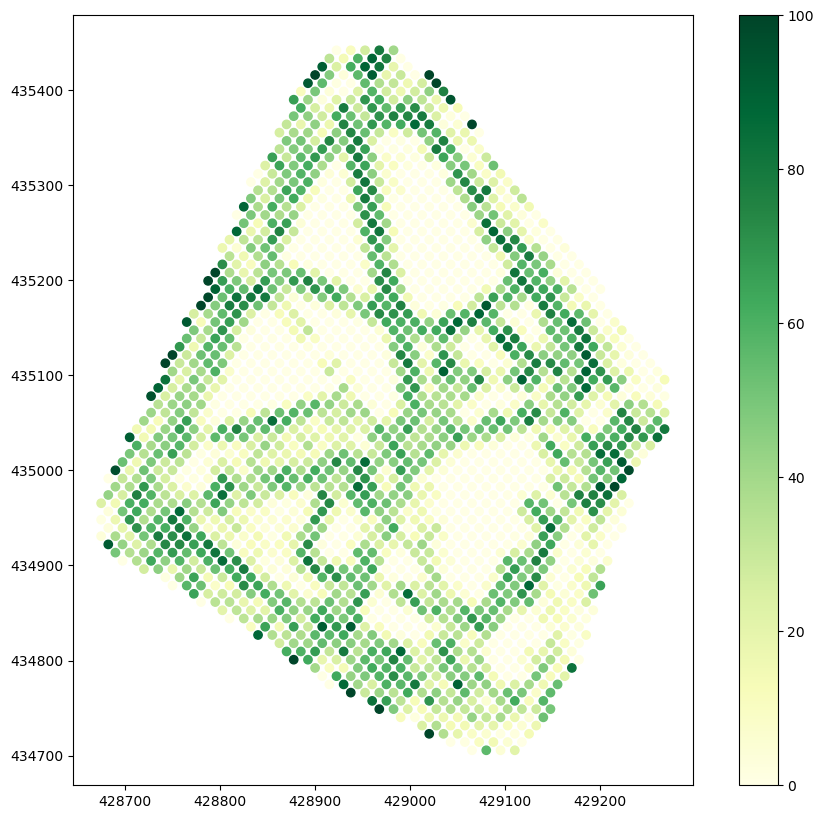

In [10]:
foliage_stats.plot(column='percent_above_1m', cmap='YlGn', legend=True, figsize=(12, 10))

Now convert to poopolygons instead of points

In [11]:
foliage_stats.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

In [13]:
park_boundary_wgs84 = park_gdf.to_crs(epsg=4326)
park_boundary = park_boundary_wgs84.geometry.iloc[0]
foliage_stats_wgs84 = foliage_stats.to_crs(epsg=4326)

In [14]:
foliage_stats_wgs84.head()

,geometry,max_height,mean_height,std_height,count_pixels,percent_cover,percent_above_1m,percent_1_2m,percent_2_5m,percent_5_10m,percent_10m_plus
0,POINT (-1.56012 53.80785),0.000999,0.000500,0.000500,2,0.000452,0.000000,0.000000,0.000000,0.000000,0.000000
1,POINT (-1.55989 53.80785),13.629997,4.036781,4.504664,73,0.016486,56.164384,6.849315,15.068493,17.808219,16.438356
2,POINT (-1.55966 53.80785),4.658997,0.151900,0.619425,110,0.024842,4.545455,2.727273,1.818182,0.000000,0.000000
3,POINT (-1.55944 53.80785),8.444000,1.093810,2.247415,42,0.009485,21.428571,4.761905,4.761905,11.904762,0.000000
4,POINT (-1.56046 53.80793),0.000000,-0.000496,0.000496,2,0.000452,0.000000,0.000000,0.000000,0.000000,0.000000


In [15]:
# Extract coordinates and values from foliage data
coords = np.array([[pt.x, pt.y] for pt in foliage_stats_wgs84.geometry])

# Create Voronoi diagram
vor = Voronoi(coords)

# Create polygons from Voronoi cells, preserving all columns
polygons = []
for point_index, region_index in enumerate(vor.point_region):
    region = vor.regions[region_index]
    if -1 not in region and len(region) > 0:
        try:
            polygon = Polygon([vor.vertices[i] for i in region])
            if polygon.is_valid:
                # Clip polygon to park boundary
                clipped = polygon.intersection(park_boundary)
                if clipped.area > 0:  # Only include if there's overlap
                    # Get all columns from original row and add geometry
                    row_data = foliage_stats_wgs84.iloc[point_index].to_dict()
                    row_data['geometry'] = clipped
                    polygons.append(row_data)
        except:
            pass

# Create GeoDataFrame with all original columns
foliage_voronoi_gdf = gpd.GeoDataFrame(polygons, crs='EPSG:4326')

print(f"Created {len(foliage_voronoi_gdf)} Voronoi polygons")
print(f"Columns: {foliage_voronoi_gdf.columns.tolist()}")
foliage_voronoi_gdf.head()

Created 2079 Voronoi polygons
Columns: ['geometry', 'max_height', 'mean_height', 'std_height', 'count_pixels', 'percent_cover', 'percent_above_1m', 'percent_1_2m', 'percent_2_5m', 'percent_5_10m', 'percent_10m_plus']


,geometry,max_height,mean_height,std_height,count_pixels,percent_cover,percent_above_1m,percent_1_2m,percent_2_5m,percent_5_10m,percent_10m_plus
0,"POLYGON ((-1.55992 53.80793, -1.55986 53.80793...",13.629997,4.036781,4.504664,73,0.016486,56.164384,6.849315,15.068493,17.808219,16.438356
1,"POLYGON ((-1.55969 53.80793, -1.55963 53.80793...",4.658997,0.151900,0.619425,110,0.024842,4.545455,2.727273,1.818182,0.000000,0.000000
2,"POLYGON ((-1.56026 53.80801, -1.5602 53.80801,...",5.131004,0.088042,0.608641,72,0.016260,1.388889,0.000000,0.000000,1.388889,0.000000
3,"POLYGON ((-1.55992 53.80793, -1.55995 53.80789...",12.877998,0.639716,2.187506,169,0.038166,10.059172,2.366864,2.366864,2.958580,2.366864
4,"POLYGON ((-1.55986 53.80793, -1.55981 53.80801...",13.629997,0.950239,2.685209,251,0.056685,14.741036,3.585657,3.585657,4.382470,3.187251


<Axes: >

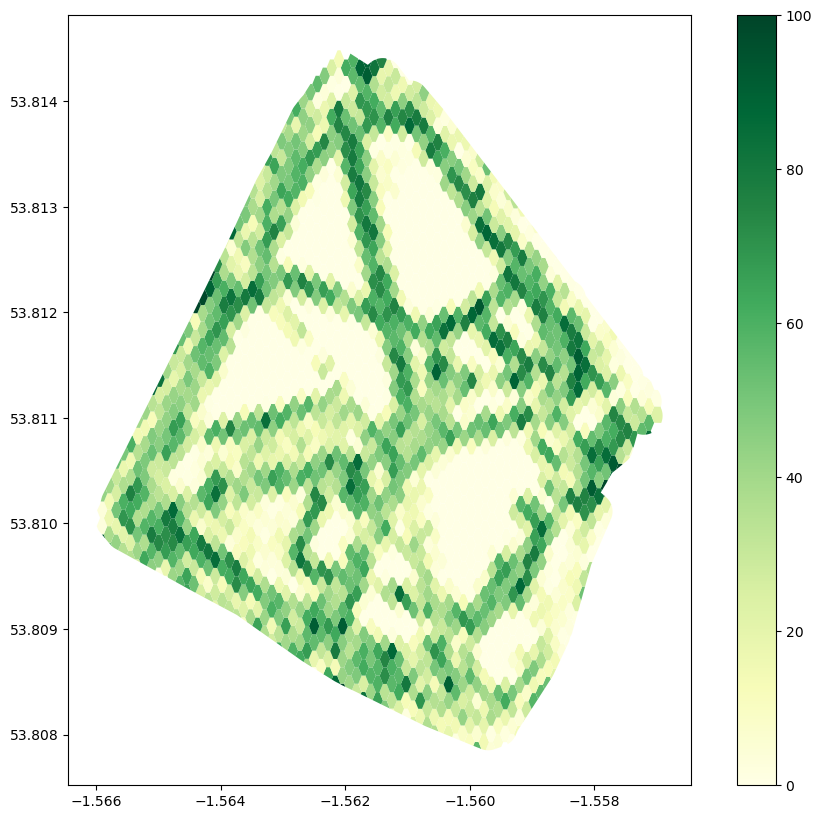

In [17]:
foliage_voronoi_gdf.plot(column='percent_above_1m', cmap='YlGn', legend=True, figsize=(12, 10))

In [19]:
# Export as GeoJSON
output_path = OUTPUT_DIR / f'{FILE_NAME}_foliage_voronoi.geojson'
foliage_voronoi_gdf.to_file(output_path, driver='GeoJSON')

# Check file size
import os
file_size = os.path.getsize(output_path) / 1024 / 1024
print(f"File size: {file_size:.2f} MB")

File size: 1.46 MB


In [20]:
foliage_voronoi_gdf_filtered = foliage_voronoi_gdf[foliage_voronoi_gdf['percent_above_1m'] > 30]

<Axes: >

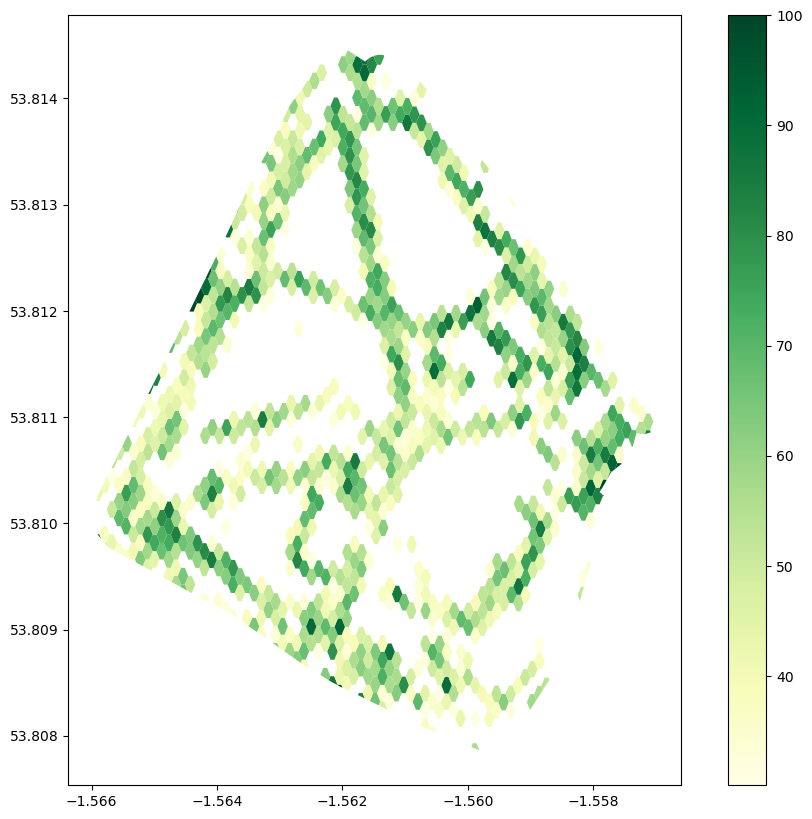

In [21]:
foliage_voronoi_gdf_filtered.plot(column='percent_above_1m', cmap='YlGn', legend=True, figsize=(12, 10))